In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as random
import cc3d

In [2]:
import numba as nb
@nb.njit
def delta_E_total(array,nnn_array,i,J=1,h=0,nnn=False):
    N=len(array)
    delta_E = -2*array[i]*(array[(i+1)%N]+array[i-1])   # add "array[(i+2)%N]+array[i-2]" to include true nnn
    
    if nnn==True:
        shuffle_index = np.argwhere(nnn_array==i)[0]
        up_index = nnn_array[(shuffle_index+1)%N][0]
        down_index = nnn_array[(shuffle_index-1)][0]
        delta_E += -2*array[i]*(array[(up_index)%N]+array[down_index])

    delta_E *= -J
    delta_E += 2*h*array[i]
    return delta_E


@nb.njit
def nn_sim(array,index,select,T,n_max=10**3,skip=10,J=1,h=0):
    m = np.array([np.sum(array)])
    for l in range(n_max):
        i = index[l]
        delta_E=delta_E_total(array,np.array([0]),i,h=h)

        if delta_E <= 0 or select[l] < np.exp(-delta_E/T):
            array[i]*=-1

        if l%skip==0:
            m = np.append(m,np.sum(array))
    return m,array

@nb.njit
def nnn_sim(array,index,select,shuffle_array,T,n_max=10**3,skip=10,J=1,h=0):
    m = np.array([np.sum(array)])

    for l in range(n_max):
        i = index[l]
        delta_E=delta_E_total(array=array,nnn_array=shuffle_array,i=i,J=J,h=h,nnn=True)
        
        if delta_E <= 0 or select[l] < np.exp(-delta_E/T):
            array[i]*=-1
        if l%skip==0:
            m = np.append(m,np.sum(array))
    return m,array

In [3]:
def initiate_run(N_site,T,n_max = 10**6,num_point=1000,nnn=False,J=1,h=0):
    array = 2*random.randint(2,size=N_site)-1
    # array = np.ones(N_site).astype(int)

    index = random.randint(N_site,size=n_max)
    select = random.rand(n_max)
    skip = int(n_max/num_point)
    if nnn==True:
        shuffle_array = np.loadtxt("nnn_array//shuffle_"+str(N_site)+".txt").astype(int)

        m,final_array = nnn_sim(array,index,select,shuffle_array,T,n_max=n_max,skip=skip,J=J,h=h)
    else:
        m,final_array = nn_sim(array,index,select,T,n_max=n_max,skip=skip,h=h)
    return m,final_array

0
3
6
9
12
15
18
21
24
27
30
33
36
39
42
45
48
51
54
57


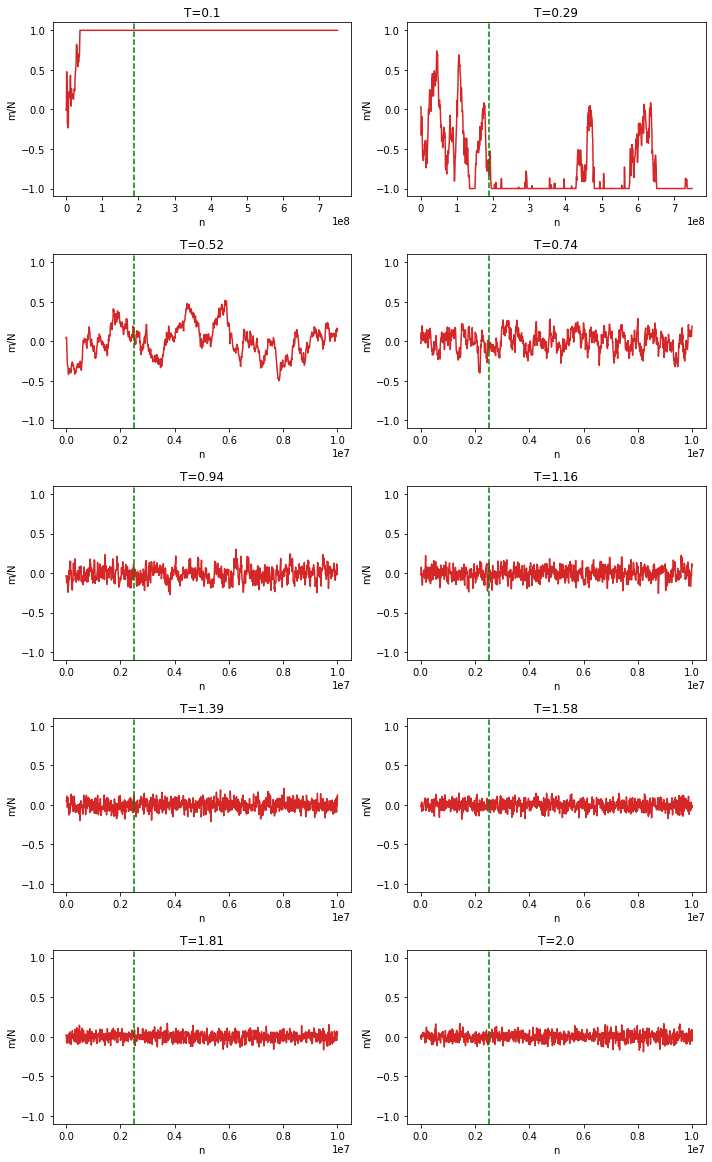

In [ ]:
# Simulate system A
N_site = 1000

determine_Tc = False
if determine_Tc ==False:
    T_list = np.linspace(0.1,2.0,60)
else:
    if N_site <= 2000:
        T_list = np.linspace(0.1,0.7,30)
    else:
         T_list = np.linspace(0.1,0.4,20)


m_mean_list = []
m_err_list = []

num_plots = 10

index_for_plot = (np.arange(0,num_plots)*len(T_list)/(num_plots-1)).astype(int).tolist()
index_for_plot[-1]+=-1

if index_for_plot:
        fig,ax = plt.subplots(int(num_plots/2),2,figsize = (20/2,13/8*num_plots))
count = 0

h=0

for index, T in enumerate(T_list):
    n_max = 10**4*N_site
    if index%3==0:
         print(index)
         
    if T<0.45:
        n_max*=3*10
        if N_site >=1000 and N_site <= 2000:
             n_max*=2.5
        if N_site > 2000:
             n_max *= 0.7           
    if N_site < 100:
        n_max*=30
    if N_site >1000 and N_site <= 2000:
        n_max*=2.5
    
    n_max=int(n_max)

    num_points = 1000
    skip = int(n_max/num_points)
    n_0=int(n_max/4)

    m,final_array=initiate_run(N_site=N_site,T=T,n_max=n_max,num_point=num_points)
    m = m/N_site

    if index in index_for_plot:
        axis = ax.flatten()[count]
        axis.plot(np.arange(len(m))*skip,m,color="tab:red")
        axis.plot([n_0,n_0],[-1.1,1.1],linestyle="dashed",color="green")
        axis.set_ylim(-1.1,1.1)
        axis.set_title("T="+str(np.round(T,2)))
        axis.set_xlabel("n")
        axis.set_ylabel("m/N")
        fig.tight_layout()
        count+=1
        
    m_mean = np.mean(m[int(n_0/skip):])
    m_mean_std = np.std(m[int(n_0/skip):])
    m_mean_list.append(m_mean)
    m_err_list.append(m_mean_std)

if determine_Tc ==False:
    fig.savefig(".//data//nn_m_plots_"+str(N_site)+".png")

plt.show()

In [6]:
save_array = np.vstack((T_list,m_mean_list,m_err_list)).T

if determine_Tc ==False:
    np.savetxt(".//Data//nn_"+str(N_site)+".txt",save_array,header="T,m,m_err")
else:
    np.savetxt(".//Data//nn_"+str(N_site)+"_Tc.txt",save_array,header="T,m,m_err")

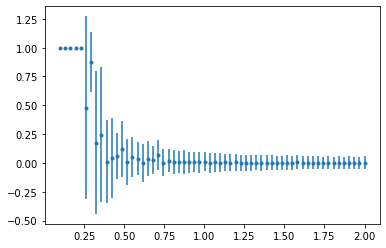

1000


In [16]:
plt.errorbar(T_list,abs(np.array(m_mean_list)),m_err_list,fmt='.')
plt.show()
print(N_site)

0
5
10
15
20
25
30
35
40
45
50
55
60
65
70


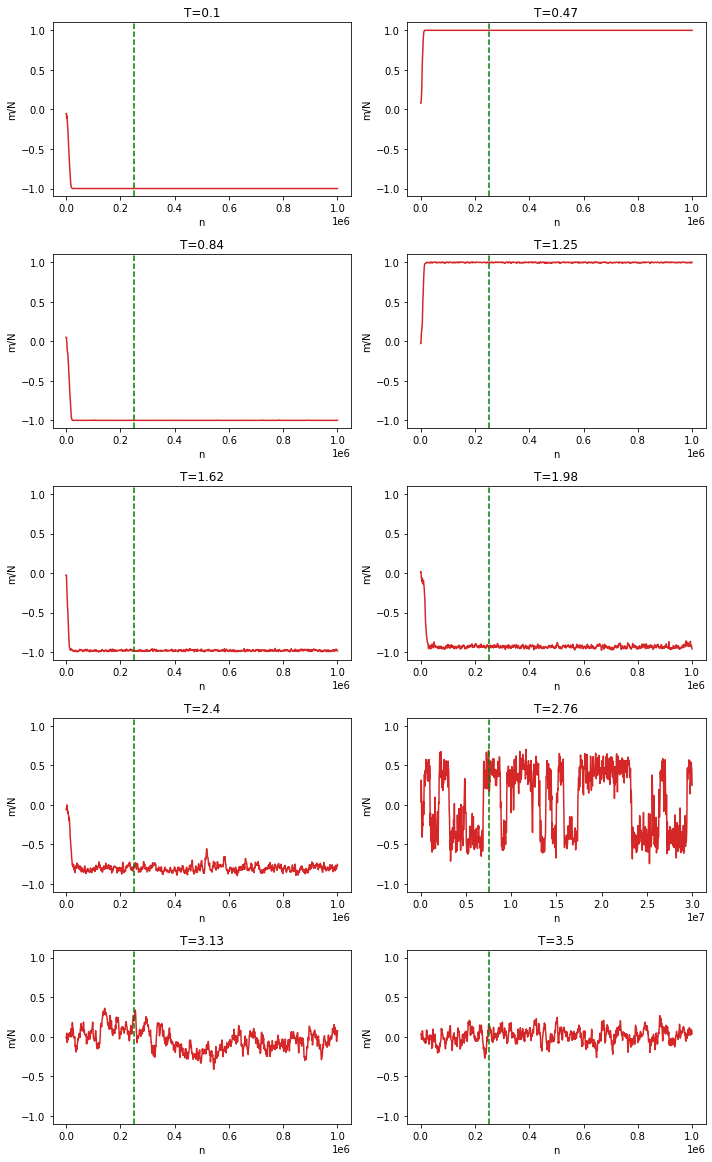

In [ ]:
# Simulate system B
N_site=1000

determine_Tc = False
if determine_Tc == False:
    T_list = np.linspace(0.1,3.5,75)
else:
    T_list = np.linspace(1.7,3.1,45)


E_mean_list = []
m_mean_list = []
domain_mean_list = []
E_err_list = []
m_err_list = []

num_plots = 10

index_for_plot = (np.arange(0,num_plots)*len(T_list)/(num_plots-1)).astype(int).tolist()
index_for_plot[-1]+=-1

if index_for_plot:
        fig,ax = plt.subplots(int(num_plots/2),2,figsize = (20/2,13/8*num_plots))
count = 0

h=0

for index, T in enumerate(T_list):
    n_max = 10**3*N_site

    if T>=2.5 and T<=3.1:
         n_max*=3*10

    if N_site<100:  
         n_max*=20
    if N_site>1000:
         n_max = 2

    n_max = int(n_max)

    num_points = 1000
    skip=int(n_max/num_points)
    n_0=int(n_max/4)

    if index%5==0:
         print(index)

    m,final_array=initiate_run(N_site,T,n_max=n_max,num_point=num_points,h=h,nnn=True)
    m = m/N_site

    if index in index_for_plot:
        axis = ax.flatten()[count]
        axis.plot(np.arange(len(m))*skip,m,color="tab:red")
        axis.plot([n_0,n_0],[-1.1,1.1],linestyle="dashed",color="green")
        axis.set_ylim(-1.1,1.1)
        axis.set_title("T="+str(np.round(T,2)))
        axis.set_xlabel("n")
        axis.set_ylabel("m/N")
        fig.tight_layout()
        count+=1


    m_mean = np.mean(m[int(n_0/skip):])
    m_mean_std = np.std(m[int(n_0/skip):])
    m_mean_list.append(m_mean)
    m_err_list.append(m_mean)

if determine_Tc == False:
    fig.savefig(".//data//nnn_m_plots_"+str(N_site)+".png")
plt.show()

In [9]:
save_array = np.vstack((T_list,m_mean_list,m_err_list)).T
print(np.shape(save_array))
if determine_Tc == False:
    np.savetxt(".//Data//nnn_"+str(N_site)+".txt",save_array,header="T,m,m_err")
else:
    print("Determine T_c")
    np.savetxt(".//Data//nnn_"+str(N_site)+"_Tc.txt",save_array,header="T,m,m_err")


(75, 3)


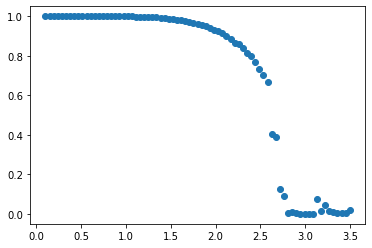

1000


In [10]:
plt.scatter(T_list,abs(np.array(m_mean_list)))
plt.show()
print(N_site)

In [11]:
def create_nnn_shuffle(N_site):
    index = np.arange(N_site)
    shuffle = [0]
    for i in range(1,N_site):
        choices = [x for x in index if (x not in shuffle) and (((x-1)%N_site-shuffle[-1]!=0)) and (((x+1)%N_site-shuffle[-1]!=0))]
        choice = random.choice(choices)
        shuffle.append(choice)

    shuffle = np.array(shuffle)
    np.savetxt("nnn_array//shuffle_"+str(N_site)+".txt",shuffle.astype(int))

create_nnn_shuffle(2000)

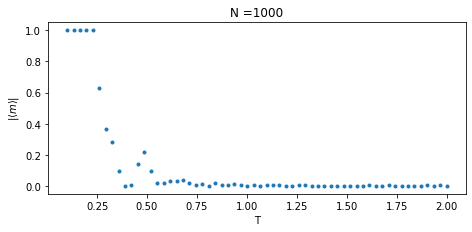

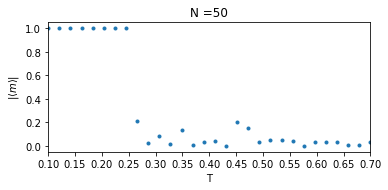

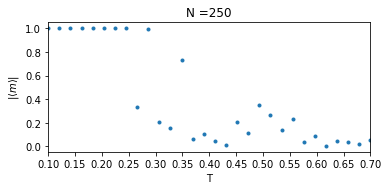

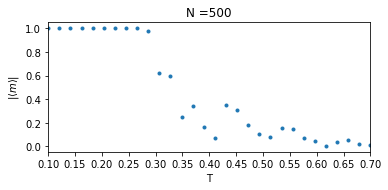

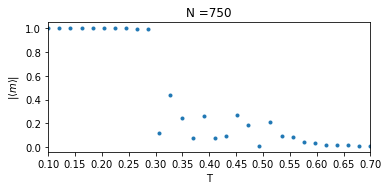

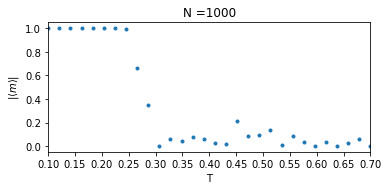

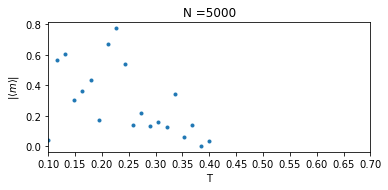

In [4]:
# Plot system A
N=1000

data  = np.genfromtxt(".//data//nn_"+str(N)+".txt")
fig,ax = plt.subplots(1,1,figsize=(10/1.5,5/1.5))
T = data[:,0]
m = data[:,1]
m_err = data[:,2]
ax.scatter(T,abs(m),marker='.')
ax.set_title("N ="+str(N))
ax.set_xlabel("T")
ax.set_ylabel(r"$|\langle m\rangle|$")
fig.tight_layout()
fig.savefig(".//Data//nn_masterplot.png")

N_list = [50,250,500,750,1000,5000]

for i,N in enumerate(N_list):
    data = np.genfromtxt(".//data//nn_"+str(N)+"_Tc.txt")
    fig,ax = plt.subplots(1,1,figsize=(10/2*1.1,5/2*1.1))
    T = data[:,0]
    m = data[:,1]
    m_err = data[:,2]
    ax.scatter(T,abs(m),marker='.')
    ax.set_xlabel("T")
    ax.set_ylabel(r"$|\langle m\rangle|$")
    ax.set_title("N ="+str(N))
    ax.set_xlim(0.1,0.7)
    ax.set_xticks([0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7])
    fig.tight_layout()
    fig.savefig(".//Data//nn_m_v_T_"+str(N)+".png")
plt.show()

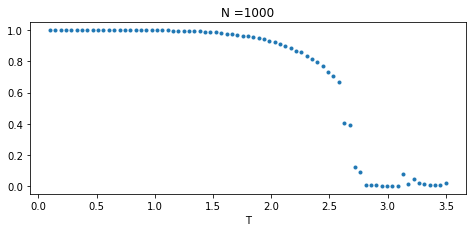

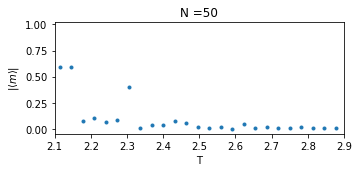

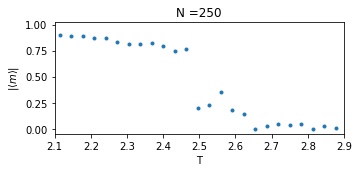

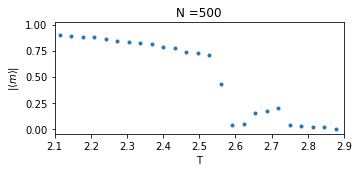

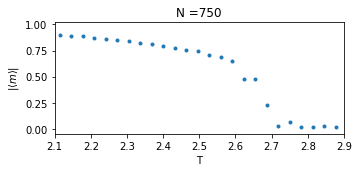

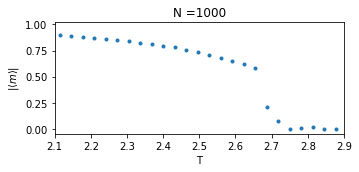

In [5]:
# Plot system B
N=1000
data  = np.genfromtxt(".//data//nnn_"+str(N)+".txt")
fig,ax = plt.subplots(1,1,figsize=(10/1.5,5/1.5))
T = data[:,0]
m = data[:,1]
m_err = data[:,2]
ax.scatter(T,abs(m),marker='.')
ax.set_title("N ="+str(N))
ax.set_xlabel("T")
fig.tight_layout()
fig.savefig(".//Data//nnn_masterplot.png")

N_list = [50,250,500,750,1000]

for i,N in enumerate(N_list):
    data = np.genfromtxt(".//data//nnn_"+str(N)+"_Tc.txt")
    fig,ax = plt.subplots(1,1,figsize=(10/2,5/2))
    T = data[:,0]
    m = data[:,1]
    m_err = data[:,2]
    ax.scatter(T,abs(m),marker='.')
    ax.set_xlabel("T")
    ax.set_ylabel(r"$|\langle m\rangle|$")
    ax.set_xlim(2.1,2.9)
    ax.set_xticks([2.1,2.2,2.3,2.4,2.5,2.6,2.7,2.8,2.9])
    ax.set_title("N ="+str(N))
    fig.tight_layout()
    fig.savefig(".//Data//nnn_m_v_T_"+str(N)+".png")
    
plt.show()

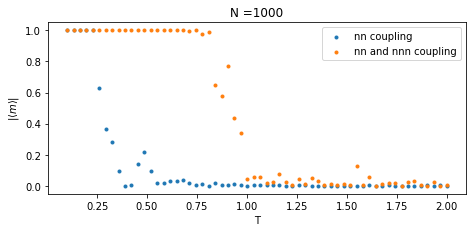

In [6]:
# compare nn and nnn neighbors
N=1000
data1  = np.genfromtxt(".//data//nn_"+str(N)+".txt")
fig,ax = plt.subplots(1,1,figsize=(10/1.5,5/1.5))
T = data1[:,0]
m = data1[:,1]
m_err = data1[:,2]
ax.scatter(T,abs(m),marker='.',label = "nn coupling")
ax.set_title("N ="+str(N))
ax.set_xlabel("T")
ax.set_ylabel(r"$|\langle m\rangle|$")

data2  = np.genfromtxt(".//Data//nnn_data.txt")
T = data2[:,0]
m = data2[:,1]
m_err = data2[:,2]
ax.scatter(T,abs(m),marker='.',label = "nn and nnn coupling")
ax.legend()
fig.tight_layout()
fig.savefig("nn_v_nnn.png")
plt.show()